In [ ]:
# ============================================================================
# Cell 0: Setup and Imports
# ============================================================================
import os
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from datetime import datetime, timezone
from collections import Counter

# Community detection
!pip install python-louvain
import community as community_louvain

# NLP
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Bluesky
from atproto import Client

# Mastodon
from mastodon import Mastodon

# Load config
import config

# Output directory
os.makedirs(config.OUTPUT_DIR, exist_ok=True)

print("Setup complete.")


In [ ]:
# ============================================================================
# Cell 1: Helper: Extract Mentions from Text
# ============================================================================
def extract_mentions(text):
    """Extract @handles from text (Bluesky/Mastodon style)"""
    if not text:
        return []
    # Pattern for @username (allow dots, underscores, hyphens)
    return re.findall(r'@([a-zA-Z0-9_.-]+)', text)

In [ ]:
# ============================================================================
# Cell 2: Bluesky Scraper (with mention network)
# ============================================================================
def scrape_bluesky_network(game, bsky_client, max_posts=700):
    """
    Scrape Bluesky posts for a game, extract mentions, build directed graph.
    Returns (list_of_posts, networkx.DiGraph).
    """
    game_name = game['name']
    term = game['search_terms'][0]  # e.g., "Baldurs Gate 3"
    cursor = None
    posts = []
    collected = 0
    G = nx.DiGraph()
    
    if bsky_client is None:
        print(f"  Bluesky client not available for {game_name}")
        return [], G
    
    while collected < max_posts:
        try:
            resp = bsky_client.app.bsky.feed.search_posts({'q': term, 'limit': 100, 'cursor': cursor})
            if not resp.posts:
                break
            for post in resp.posts:
                text = post.record.text
                author = post.author.handle
                mentions = extract_mentions(text)
                posts.append({
                    'game': game_name,
                    'text': text,
                    'author': author,
                    'created_at': post.indexed_at,
                    'like_count': post.like_count,
                    'repost_count': post.repost_count,
                    'reply_count': post.reply_count,
                    'mentions': mentions
                })
                # Add nodes and edges
                G.add_node(author)
                for m in mentions:
                    G.add_node(m)
                    G.add_edge(author, m)  # directed: author mentions m
                collected += 1
                if collected >= max_posts:
                    break
            cursor = resp.cursor
            if not cursor:
                break
            time.sleep(config.REQUEST_DELAY)
        except Exception as e:
            print(f"  Error: {e}")
            break
    
    if posts:
        df = pd.DataFrame(posts)
        df.to_csv(f"{config.OUTPUT_DIR}/{game_name}_bluesky.csv", index=False)
        print(f"  Saved {len(posts)} posts, network has {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    else:
        print(f"  No posts found for {game_name}")
    return posts, G

# Initialize Bluesky
try:
    bsky = Client()
    bsky.login("user", "password")
    print("Bluesky login successful")
except Exception as e:
    print(f"Bluesky login failed: {e}")
    bsky = None

all_bluesky_posts = []
all_bluesky_graphs = []
for game in config.GAMES:  # Use all games from config
    print(f"\nScraping Bluesky for {game['name']}...")
    posts, G = scrape_bluesky_network(game, bsky, max_posts=700)
    all_bluesky_posts.extend(posts)
    all_bluesky_graphs.append(G)

Bluesky login successful

Scraping Bluesky for Baldur's Gate 3...
  Saved 700 posts, network has 567 nodes, 44 edges

Scraping Bluesky for Palworld...
  Saved 700 posts, network has 501 nodes, 85 edges

Scraping Bluesky for Helldivers 2...
  Saved 700 posts, network has 623 nodes, 111 edges

Scraping Bluesky for Black Myth Wukong...
  Saved 700 posts, network has 381 nodes, 13 edges

Scraping Bluesky for Manor Lords...
  Saved 700 posts, network has 470 nodes, 29 edges

Scraping Bluesky for Hades II...
  Saved 700 posts, network has 616 nodes, 33 edges

Scraping Bluesky for Elden Ring Shadow of the Erdtree...
  Saved 700 posts, network has 422 nodes, 19 edges

Scraping Bluesky for Satisfactory 1.0...
  Saved 700 posts, network has 532 nodes, 37 edges

Scraping Bluesky for Path of Exile 2...
  Saved 700 posts, network has 500 nodes, 53 edges

Scraping Bluesky for Warhammer 40K Space Marine 2...
  Saved 700 posts, network has 531 nodes, 53 edges


In [39]:
# ============================================================================
# Cell 3: Mastodon Scraper (with mention network)
# ============================================================================
def scrape_mastodon_network(game, max_toots=700):
    game_name = game['name']
    tags = game['mastodon_tags']
    mastodon = Mastodon(api_base_url=config.MASTODON['base_url'])
    toots = []
    G = nx.DiGraph()
    
    for tag in tags:
        print(f"  Searching #{tag}")
        try:
            results = mastodon.timeline_hashtag(tag, local=False, limit=max_toots)
            for toot in results:
                content = toot['content']
                # Remove HTML tags
                content = re.sub(r'<[^>]+>', '', content)
                author = toot['account']['acct']
                mentions = [m['acct'] for m in toot['mentions']]
                toots.append({
                    'game': game_name,
                    'text': content,
                    'author': author,
                    'created_at': toot['created_at'].isoformat(),
                    'reblogs_count': toot['reblogs_count'],
                    'favourites_count': toot['favourites_count'],
                    'mentions': mentions
                })
                G.add_node(author)
                for m in mentions:
                    G.add_node(m)
                    G.add_edge(author, m)
            time.sleep(config.REQUEST_DELAY)
        except Exception as e:
            print(f"    Error: {e}")
    
    if toots:
        df = pd.DataFrame(toots)
        df.to_csv(f"{config.OUTPUT_DIR}/{game_name}_mastodon.csv", index=False)
        print(f"  Saved {len(toots)} toots, network has {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    else:
        print(f"  No toots found for {game_name}")
    return toots, G

all_mastodon_toots = []
all_mastodon_graphs = []
for game in config.GAMES:
    print(f"\nScraping Mastodon for {game['name']}...")
    toots, G = scrape_mastodon_network(game, max_toots=700)
    all_mastodon_toots.extend(toots)
    all_mastodon_graphs.append(G)


Scraping Mastodon for Baldur's Gate 3...
  Searching #BaldursGate3
  Searching #BG3
  Saved 80 toots, network has 51 nodes, 3 edges

Scraping Mastodon for Palworld...
  Searching #Palworld
  Saved 40 toots, network has 5 nodes, 0 edges

Scraping Mastodon for Helldivers 2...
  Searching #Helldivers2
  Saved 40 toots, network has 19 nodes, 0 edges

Scraping Mastodon for Black Myth Wukong...
  Searching #BlackMythWukong
  Searching #BlackMyth
  Saved 80 toots, network has 38 nodes, 0 edges

Scraping Mastodon for Manor Lords...
  Searching #ManorLords
  Saved 40 toots, network has 31 nodes, 6 edges

Scraping Mastodon for Hades II...
  Searching #HadesII
  Searching #Hades2
  Saved 80 toots, network has 41 nodes, 3 edges

Scraping Mastodon for Elden Ring Shadow of the Erdtree...
  Searching #EldenRing
  Searching #ShadowOfTheErdtree
  Saved 80 toots, network has 39 nodes, 1 edges

Scraping Mastodon for Satisfactory 1.0...
  Searching #Satisfactory
  Searching #SatisfactoryGame
  Saved 80 t

In [49]:
# ============================================================================
# Cell 3.5: Reddit Scraper (Polite, Simple Delays)
# ============================================================================
import requests
import time
import pandas as pd
import networkx as nx

def scrape_reddit_network(game, max_posts=20, delay_between_requests=2.0):
    """
    Scrape Reddit posts and comments with delays to avoid 429.
    """
    game_name = game['name']
    subreddits = game['reddit_subreddits']
    search_terms = game['search_terms']
    query = ' OR '.join(search_terms)
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    
    all_posts = []
    all_comments = []
    G = nx.DiGraph()
    
    for sub in subreddits:
        print(f"  Searching r/{sub} ...")
        url = f"https://www.reddit.com/r/{sub}/search.json"
        params = {'q': query, 'sort': 'relevance', 'limit': max_posts, 't': 'month'}
        try:
            resp = requests.get(url, params=params, headers=headers, timeout=15)
            if resp.status_code != 200:
                print(f"    HTTP {resp.status_code} – skipping")
                continue
            data = resp.json()
            posts = data.get('data', {}).get('children', [])
            print(f"    Found {len(posts)} posts")
            
            for child in posts:
                post = child['data']
                post_id = post['id']
                post_author = post['author']
                all_posts.append({
                    'game': game_name,
                    'subreddit': sub,
                    'post_id': post_id,
                    'title': post['title'],
                    'selftext': post['selftext'],
                    'score': post['score'],
                    'num_comments': post['num_comments'],
                    'created_utc': post['created_utc'],
                    'author': post_author
                })
                
                # Fetch comments for this post – add a delay before each comment request
                time.sleep(delay_between_requests)
                comments_url = f"https://www.reddit.com/comments/{post_id}.json"
                try:
                    c_resp = requests.get(comments_url, headers=headers, timeout=10)
                    if c_resp.status_code == 200:
                        comments_data = c_resp.json()
                        if len(comments_data) > 1:
                            # Extract reply relationships
                            def extract_replies(comment_tree, parent_author=None):
                                for item in comment_tree:
                                    if item.get('kind') == 't1':
                                        c = item['data']
                                        author = c['author']
                                        if author != '[deleted]' and parent_author and parent_author != '[deleted]':
                                            G.add_edge(author, parent_author)
                                            all_comments.append({
                                                'game': game_name,
                                                'post_id': post_id,
                                                'comment_id': c['id'],
                                                'author': author,
                                                'parent_author': parent_author,
                                                'body': c['body'],
                                                'score': c['score'],
                                                'created_utc': c['created_utc']
                                            })
                                        if 'replies' in c and c['replies']:
                                            replies = c['replies']['data']['children']
                                            extract_replies(replies, author)
                            top_comments = comments_data[1]['data']['children']
                            extract_replies(top_comments, post_author)
                except Exception as e:
                    print(f"      Error fetching comments for {post_id}: {e}")
                
                # Delay between posts
                time.sleep(delay_between_requests)
                
            # Delay between subreddits
            time.sleep(delay_between_requests * 2)
        except Exception as e:
            print(f"    Error: {e}")
    
    if all_posts:
        pd.DataFrame(all_posts).to_csv(f"{config.OUTPUT_DIR}/{game_name}_reddit_posts.csv", index=False)
        print(f"  Saved {len(all_posts)} posts")
    if all_comments:
        pd.DataFrame(all_comments).to_csv(f"{config.OUTPUT_DIR}/{game_name}_reddit_comments.csv", index=False)
        print(f"  Saved {len(all_comments)} comments")
    print(f"  Network has {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return all_posts, all_comments, G

# Run for all games with longer delays
all_reddit_posts = []
all_reddit_comments = []
all_reddit_graphs = []

for game in config.GAMES:
    print(f"\nScraping Reddit for {game['name']}...")
    # Increase delay to 3 seconds to be very polite
    posts, comments, G = scrape_reddit_network(game, max_posts=50, delay_between_requests=2.0)
    all_reddit_posts.extend(posts)
    all_reddit_comments.extend(comments)
    all_reddit_graphs.append(G)


Scraping Reddit for Baldur's Gate 3...
  Searching r/BaldursGate3 ...
    Found 50 posts
  Searching r/DnD ...
    Found 50 posts
  Searching r/gaming ...
    Found 50 posts
  Saved 150 posts
  Saved 16906 comments
  Network has 4461 nodes, 5454 edges

Scraping Reddit for Palworld...
  Searching r/Palworld ...
    Found 50 posts
  Searching r/gaming ...
    Found 50 posts
  Searching r/Games ...
    Found 50 posts
  Saved 150 posts
  Saved 20730 comments
  Network has 6208 nodes, 6986 edges

Scraping Reddit for Helldivers 2...
  Searching r/Helldivers ...
    Found 50 posts
  Searching r/gaming ...
    Found 50 posts
  Searching r/Games ...
    Found 50 posts
  Saved 150 posts
  Saved 5453 comments
  Network has 1371 nodes, 1691 edges

Scraping Reddit for Black Myth Wukong...
  Searching r/BlackMythWukong ...
    Found 50 posts
  Searching r/gaming ...
    Found 50 posts
  Searching r/Games ...
    Found 50 posts
  Saved 150 posts
  Saved 9382 comments
  Network has 2185 nodes, 2877 e

In [50]:
# ============================================================================
# Resume Scraping for Missing Games (Gentler Settings)
# ============================================================================
import os
import time
import pandas as pd
import networkx as nx

def scrape_reddit_gentle(game, max_posts=10, delay=6.0):
    """
    Gentle scraper for missing games – lower volume, longer delays.
    """
    game_name = game['name']
    subreddits = game['reddit_subreddits']
    search_terms = game['search_terms']
    query = ' OR '.join(search_terms)
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    
    all_posts = []
    all_comments = []
    G = nx.DiGraph()
    
    for sub in subreddits:
        print(f"  Searching r/{sub} ...")
        url = f"https://www.reddit.com/r/{sub}/search.json"
        params = {'q': query, 'sort': 'relevance', 'limit': max_posts, 't': 'month'}
        try:
            resp = requests.get(url, params=params, headers=headers, timeout=15)
            if resp.status_code != 200:
                print(f"    HTTP {resp.status_code} – skipping")
                continue
            data = resp.json()
            posts = data.get('data', {}).get('children', [])
            print(f"    Found {len(posts)} posts")
            
            for child in posts:
                post = child['data']
                post_id = post['id']
                post_author = post['author']
                all_posts.append({
                    'game': game_name,
                    'subreddit': sub,
                    'post_id': post_id,
                    'title': post['title'],
                    'selftext': post['selftext'],
                    'score': post['score'],
                    'num_comments': post['num_comments'],
                    'created_utc': post['created_utc'],
                    'author': post_author
                })
                
                time.sleep(delay)  # longer delay before comment fetch
                comments_url = f"https://www.reddit.com/comments/{post_id}.json"
                try:
                    c_resp = requests.get(comments_url, headers=headers, timeout=10)
                    if c_resp.status_code == 200:
                        comments_data = c_resp.json()
                        if len(comments_data) > 1:
                            def extract_replies(comment_tree, parent_author=None):
                                for item in comment_tree:
                                    if item.get('kind') == 't1':
                                        c = item['data']
                                        author = c['author']
                                        if author != '[deleted]' and parent_author and parent_author != '[deleted]':
                                            G.add_edge(author, parent_author)
                                            all_comments.append({
                                                'game': game_name,
                                                'post_id': post_id,
                                                'comment_id': c['id'],
                                                'author': author,
                                                'parent_author': parent_author,
                                                'body': c['body'],
                                                'score': c['score'],
                                                'created_utc': c['created_utc']
                                            })
                                        if 'replies' in c and c['replies']:
                                            replies = c['replies']['data']['children']
                                            extract_replies(replies, author)
                            top_comments = comments_data[1]['data']['children']
                            extract_replies(top_comments, post_author)
                except Exception as e:
                    print(f"      Error fetching comments for {post_id}: {e}")
                
                time.sleep(delay)  # delay between posts
            time.sleep(delay * 1.5)  # extra delay between subreddits
        except Exception as e:
            print(f"    Error: {e}")
    
    if all_posts:
        pd.DataFrame(all_posts).to_csv(f"{config.OUTPUT_DIR}/{game_name}_reddit_posts.csv", index=False)
        print(f"  Saved {len(all_posts)} posts")
    if all_comments:
        pd.DataFrame(all_comments).to_csv(f"{config.OUTPUT_DIR}/{game_name}_reddit_comments.csv", index=False)
        print(f"  Saved {len(all_comments)} comments")
    print(f"  Network has {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return all_posts, all_comments, G

# Identify missing games (no posts file or file is very small)
missing_games = []
for game in config.GAMES:
    posts_file = f"{config.OUTPUT_DIR}/{game['name']}_reddit_posts.csv"
    if not os.path.exists(posts_file) or os.path.getsize(posts_file) < 500:  # tiny file = failed
        missing_games.append(game)

print(f"\nGames missing Reddit data: {[g['name'] for g in missing_games]}")

# Scrape only missing games with gentle settings
for game in missing_games:
    print(f"\nGentle scraping for {game['name']}...")
    scrape_reddit_gentle(game, max_posts=50, delay=3.0)


Games missing Reddit data: ['Elden Ring Shadow of the Erdtree', 'Satisfactory 1.0', 'Path of Exile 2', 'Warhammer 40K Space Marine 2']

Gentle scraping for Elden Ring Shadow of the Erdtree...
  Searching r/Eldenring ...
    Found 50 posts
  Searching r/fromsoftware ...
    Found 50 posts
  Searching r/gaming ...
    Found 50 posts
  Saved 150 posts
  Saved 2853 comments
  Network has 609 nodes, 827 edges

Gentle scraping for Satisfactory 1.0...
  Searching r/SatisfactoryGame ...
    Found 50 posts
  Searching r/gaming ...
    Found 50 posts
  Saved 100 posts
  Saved 8446 comments
  Network has 3113 nodes, 3965 edges

Gentle scraping for Path of Exile 2...
  Searching r/pathofexile2 ...
    Found 50 posts
  Searching r/pathofexile ...
    Found 50 posts
  Searching r/gaming ...
    Found 50 posts
  Saved 150 posts
  Saved 8016 comments
  Network has 2024 nodes, 2528 edges

Gentle scraping for Warhammer 40K Space Marine 2...
  Searching r/spacemarine ...
    Found 50 posts
  Searching r


Reddit Network Analysis
Nodes: 15955
Edges: 19408

Top 10 most influential users (in-degree):
  Yujin-Ha: 226 times
  Gaming-Academy: 189 times
  MapRevolutionary752: 177 times
  Primary-Pattern6868: 164 times
  ammohitchaprana: 149 times
  Euphoric_Juggernaut6: 136 times
  AkArUi_Daru: 130 times
  Thorceanswastaken: 129 times
  Hot_Mongoose_3741: 126 times
  Gjore: 124 times

Top 10 most active users (out-degree):
  AutoModerator: replied to 56 others
  Own_Trip_1593: replied to 48 others
  -leblanc_customer-: replied to 29 others
  LunarGamingYoutube: replied to 26 others
  kritihearys: replied to 25 others
  Havsglimt: replied to 20 others
  saksa39: replied to 20 others
  T_Rawww94: replied to 20 others
  DistrictMission6723: replied to 19 others
  lost_10_mm_socket: replied to 18 others

Graph too large for exact betweenness; skipping.

Top 10 PageRank influencers:
  Yujin-Ha: 0.0249
  Gjore: 0.0117
  JayomaW: 0.0099
  21MayDay21: 0.0094
  Infinity_X_: 0.0083
  MapRevolutionary75

C:\Users\mathi\AppData\Local\Temp\ipykernel_20736\1000948477.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


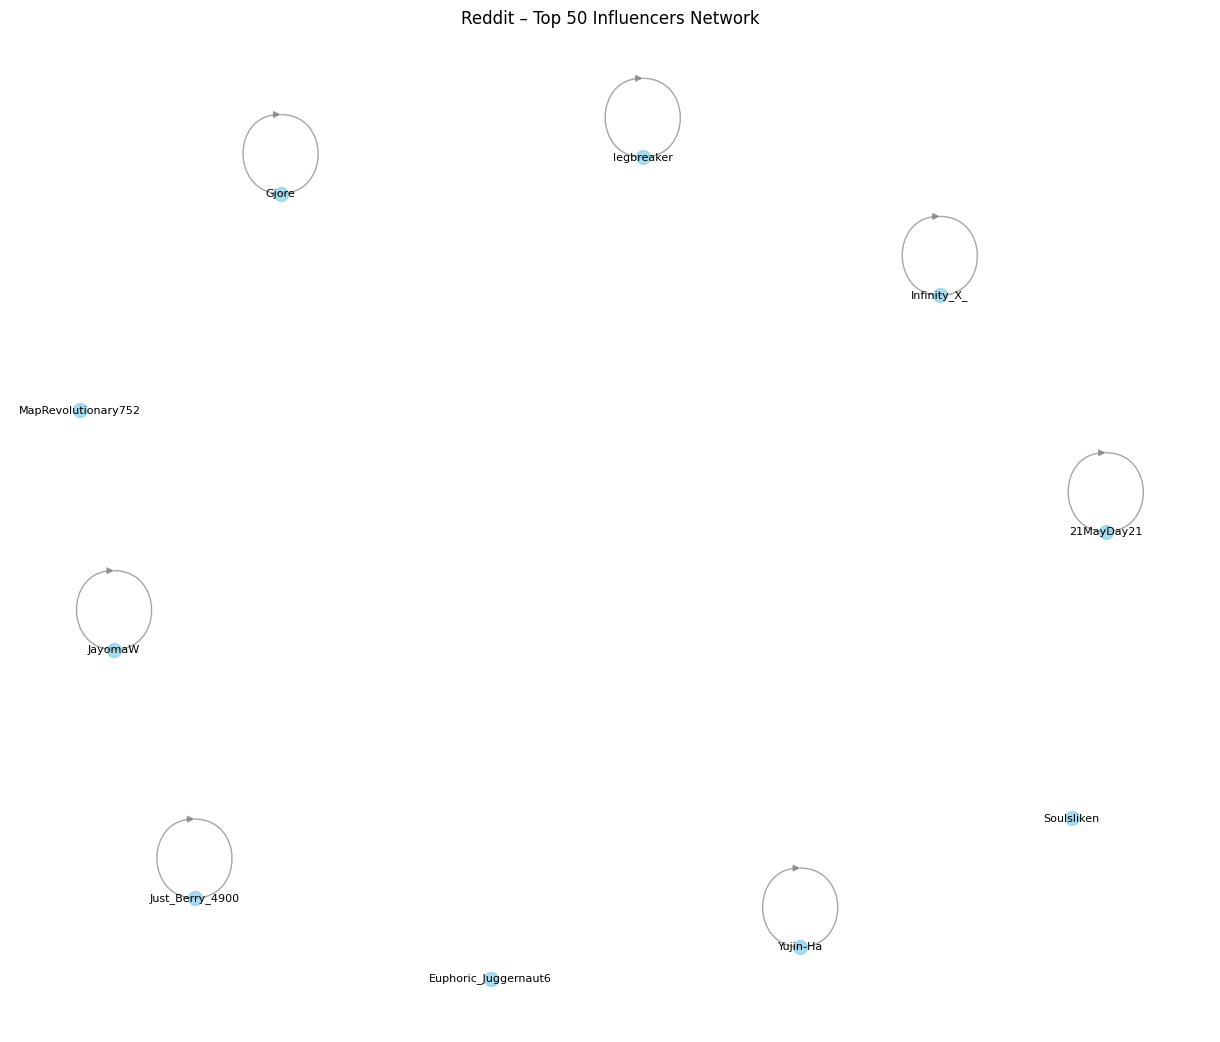

Largest connected component: 14634 nodes, 17748 edges


C:\Users\mathi\AppData\Local\Temp\ipykernel_20736\1000948477.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


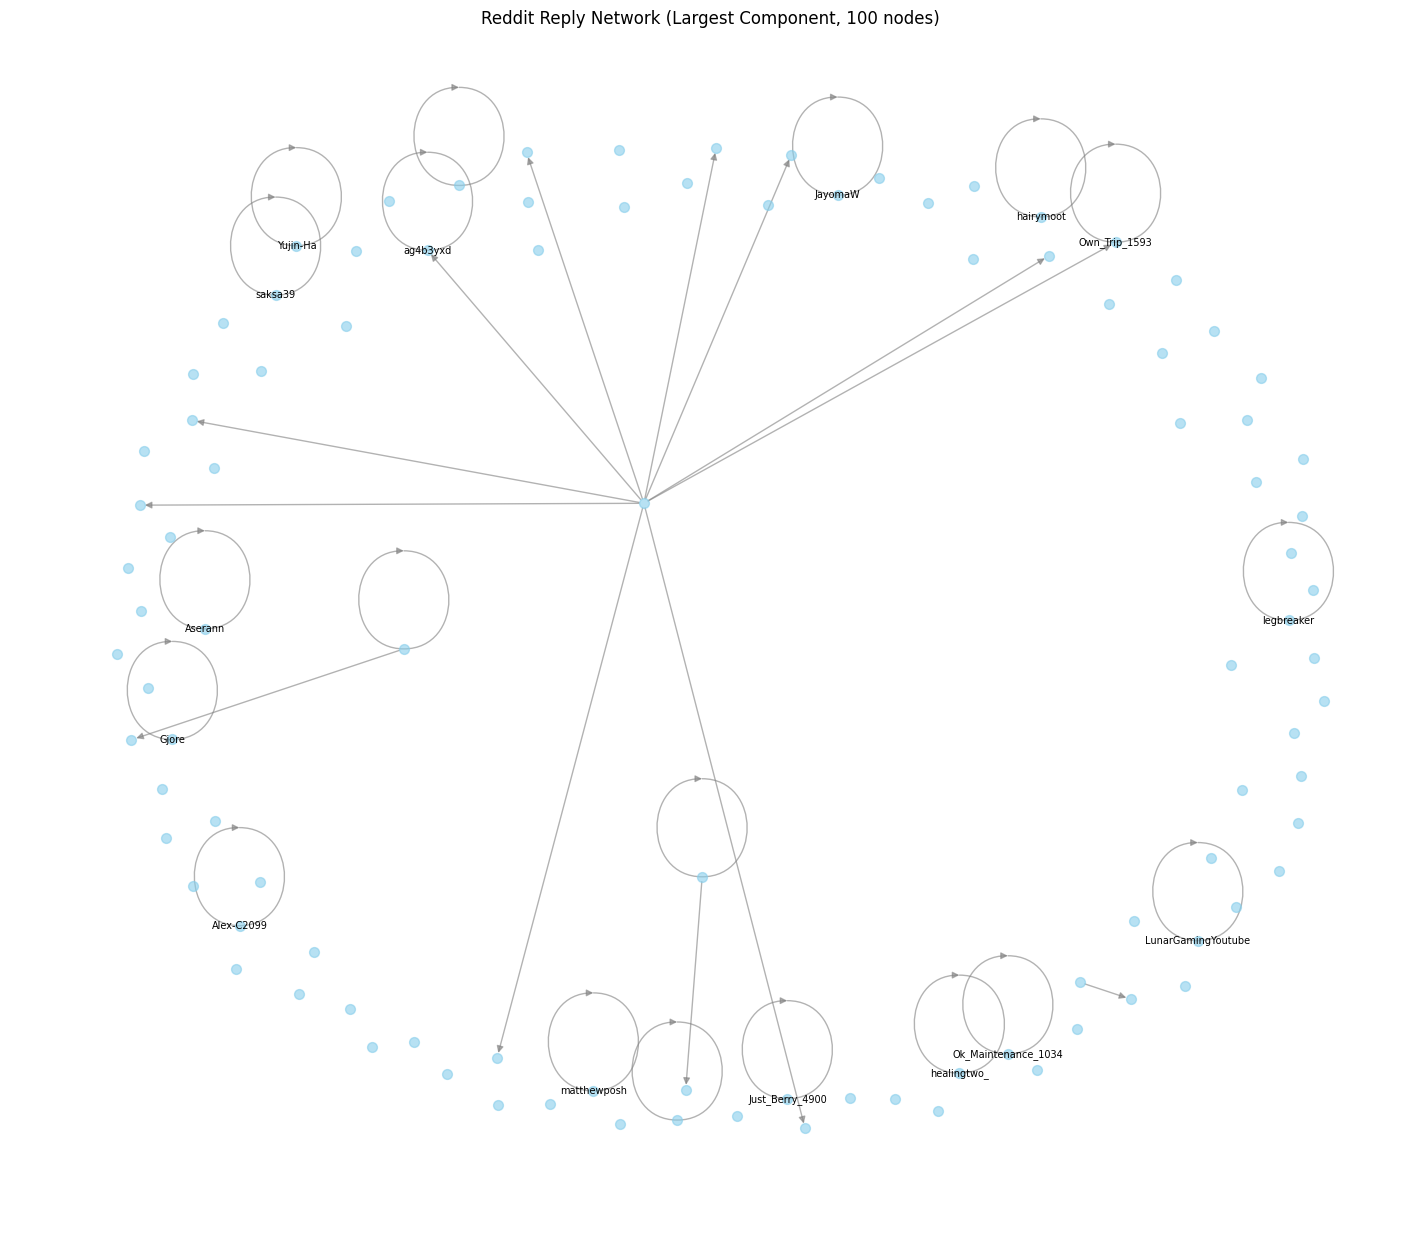


Bluesky Network Analysis
Nodes: 706
Edges: 466

Top 10 most mentioned users (in-degree):
  hoodedhorse.bsky.social: mentioned 6 times
  palworld-official.bsky.social: mentioned 3 times
  supergiantgames.bsky.social: mentioned 3 times
  smstsupport.bsky.social: mentioned 2 times
  YouTube: mentioned 2 times
  lanyanlaveno.bsky.social: mentioned 2 times
  liveonezerolp.bsky.social: mentioned 2 times
  midgivt.bsky.social: mentioned 2 times
  ravenkowai.bsky.social: mentioned 2 times
  ruranstardust.bsky.social: mentioned 2 times

Top 10 most active mentioners (out-degree):
  jaybirb.games: mentioned 17 others
  ctrlaltdeals.bsky.social: mentioned 10 others
  chasingdings.com: mentioned 7 others
  kroyvr.bsky.social: mentioned 7 others
  lucifervt.bsky.social: mentioned 6 others
  pankraru.bsky.social: mentioned 6 others
  streamingcat.bsky.social: mentioned 5 others
  avasnow.bsky.social: mentioned 5 others
  soulstone.bsky.social: mentioned 5 others
  lunaraara.bsky.social: mentioned 5

In [55]:
import pandas as pd
import networkx as nx
from collections import Counter
import community as community_louvain
import matplotlib.pyplot as plt

# ============================================================================
# Cell 4: Combine All Networks & Analyze (Reddit + Bluesky + Mastodon)
# ============================================================================

def analyze_network(G, platform_name):
    """Print and visualize network metrics."""
    if G.number_of_nodes() == 0:
        print(f"{platform_name}: No network data.")
        return
    
    print(f"\n{'='*50}")
    print(f"{platform_name} Network Analysis")
    print(f"{'='*50}")
    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")
    
    # In-degree (being replied to / mentioned)
    in_degree = dict(G.in_degree())
    top_influential = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\nTop 10 most influential users (in-degree):")
    for user, count in top_influential:
        print(f"  {user}: {count} times")
    
    # Out-degree (replying to others)
    out_degree = dict(G.out_degree())
    top_active = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\nTop 10 most active users (out-degree):")
    for user, count in top_active:
        print(f"  {user}: replied to {count} others")
    
    # Betweenness centrality (if graph is not too large)
    if G.number_of_nodes() < 1000:
        betweenness = nx.betweenness_centrality(G)
        top_between = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
        print("\nTop 5 betweenness centrality (bridges):")
        for user, score in top_between:
            print(f"  {user}: {score:.4f}")
    else:
        print("\nGraph too large for exact betweenness; skipping.")
    
    # PageRank
    pagerank = nx.pagerank(G)
    top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\nTop 10 PageRank influencers:")
    for user, score in top_pr:
        print(f"  {user}: {score:.4f}")
    
    # Community detection
    if G.number_of_edges() > 0:
        G_undir = G.to_undirected()
        partition = community_louvain.best_partition(G_undir)
        print(f"\nNumber of communities detected: {len(set(partition.values()))}")
        community_sizes = Counter(partition.values())
        largest_comms = community_sizes.most_common(3)
        print("Largest communities (size):")
        for comm, size in largest_comms:
            print(f"  Community {comm}: {size} users")
    else:
        print("\nNo edges – cannot perform community detection.")
    
    # Visualization (top 50 nodes by PageRank)
    if G.number_of_nodes() > 0 and G.number_of_edges() > 0:
        top_nodes = [u for u, _ in top_pr[:50] if u in G.nodes]
        subG = G.subgraph(top_nodes)
        plt.figure(figsize=(12, 10))
        pos = nx.spring_layout(subG, seed=42)
        nx.draw(subG, pos, node_size=100, with_labels=False, node_color='skyblue', edge_color='gray', alpha=0.7)
        top_10_nodes = [u for u, _ in top_pr[:10] if u in subG.nodes]
        labels = {u: u for u in top_10_nodes}
        nx.draw_networkx_labels(subG, pos, labels, font_size=8)
        plt.title(f"{platform_name} – Top 50 Influencers Network")
        plt.tight_layout()
        plt.show()
    else:
        print(f"\n{platform_name}: Not enough nodes/edges for visualization.")

# Combine Reddit graphs
combined_reddit = nx.DiGraph()
for G in all_reddit_graphs:
    combined_reddit.add_edges_from(G.edges())
analyze_network(combined_reddit, "Reddit")

def analyze_network(G, platform_name):
    """Print and visualize network metrics."""
    if G.number_of_nodes() == 0:
        print(f"{platform_name}: No network data.")
        return
    
    print(f"\n{'='*50}")
    print(f"{platform_name} Network Analysis")
    print(f"{'='*50}")
    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")
    
    # In-degree (being mentioned)
    in_degree = dict(G.in_degree())
    top_influential = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\nTop 10 most mentioned users (in-degree):")
    for user, count in top_influential:
        print(f"  {user}: mentioned {count} times")
    
    # Out-degree (mentioning others) – identifies active users
    out_degree = dict(G.out_degree())
    top_active = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\nTop 10 most active mentioners (out-degree):")
    for user, count in top_active:
        print(f"  {user}: mentioned {count} others")
    
    # Betweenness centrality (only for moderately sized graphs)
    if G.number_of_nodes() < 500:
        betweenness = nx.betweenness_centrality(G)
        top_between = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
        print("\nTop 5 betweenness centrality (bridges):")
        for user, score in top_between:
            print(f"  {user}: {score:.4f}")
    else:
        print("\nGraph too large for exact betweenness; skipping.")
    
    # PageRank
    pagerank = nx.pagerank(G)
    top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\nTop 10 PageRank influencers:")
    for user, score in top_pr:
        print(f"  {user}: {score:.4f}")
    
    # Community detection (Louvain) – only if graph has edges
    if G.number_of_edges() > 0:
        G_undir = G.to_undirected()
        partition = community_louvain.best_partition(G_undir)
        print(f"\nNumber of communities detected: {len(set(partition.values()))}")
        community_sizes = Counter(partition.values())
        largest_comms = community_sizes.most_common(3)
        print("Largest communities (size):")
        for comm, size in largest_comms:
            print(f"  Community {comm}: {size} users")
    else:
        print("\nNo edges – cannot perform community detection.")
    
# Better visualization for Reddit network
if combined_reddit.number_of_nodes() > 0 and combined_reddit.number_of_edges() > 0:
    # Get the largest connected component (undirected)
    G_undir = combined_reddit.to_undirected()
    largest_cc = max(nx.connected_components(G_undir), key=len)
    G_largest = combined_reddit.subgraph(largest_cc)
    print(f"Largest connected component: {G_largest.number_of_nodes()} nodes, {G_largest.number_of_edges()} edges")
    
    # If the largest component is still huge, sample top degree nodes
    if G_largest.number_of_nodes() > 200:
        # Take top 100 nodes by degree
        degrees = dict(G_largest.degree())
        top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:100]
        G_viz = G_largest.subgraph(top_nodes)
    else:
        G_viz = G_largest
    
    plt.figure(figsize=(14, 12))
    pos = nx.spring_layout(G_viz, seed=42, k=0.3, iterations=50)
    nx.draw(G_viz, pos, node_size=50, with_labels=False, node_color='skyblue', edge_color='gray', alpha=0.6)
    # Label top 15 PageRank nodes
    pr = nx.pagerank(G_viz)
    top_pr_nodes = sorted(pr, key=pr.get, reverse=True)[:15]
    labels = {n: n for n in top_pr_nodes if n in G_viz.nodes}
    nx.draw_networkx_labels(G_viz, pos, labels, font_size=7)
    plt.title(f"Reddit Reply Network (Largest Component, {G_viz.number_of_nodes()} nodes)")
    plt.tight_layout()
    plt.show()
else:
    print("Reddit network has no edges for visualization.")

# Combine all Bluesky graphs
combined_bluesky = nx.DiGraph()
for G in all_bluesky_graphs:
    combined_bluesky.add_edges_from(G.edges())
analyze_network(combined_bluesky, "Bluesky")

# Combine all Mastodon graphs
combined_mastodon = nx.DiGraph()
for G in all_mastodon_graphs:
    combined_mastodon.add_edges_from(G.edges())
analyze_network(combined_mastodon, "Mastodon")

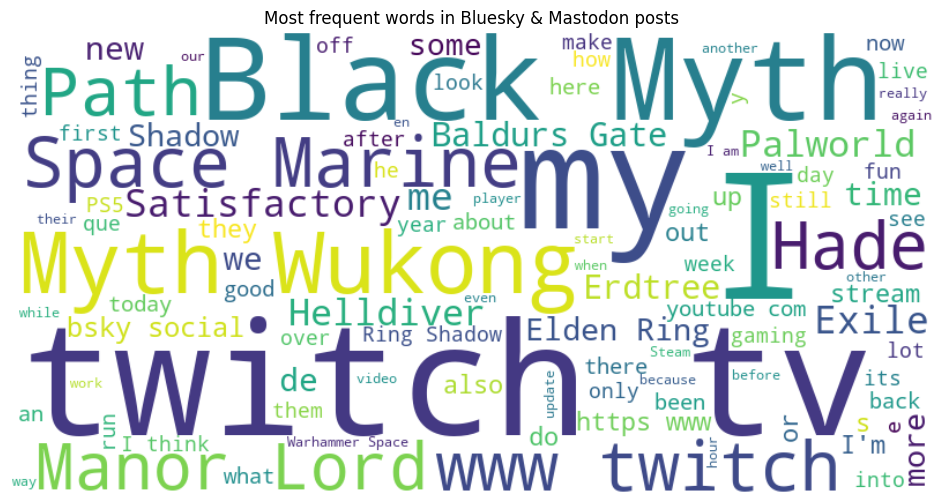


Topic Modeling Results (LDA):
Topic 1: https, youtu, erdtree, shadow, elden, ring, que, myth, wukong, black
Topic 2: stream, com, bsky, helldivers, social, palworld, live, www, tv, twitch
Topic 3: 40k, royal, persona, com, 000, 40, plus, warhammer, marine, space
Topic 4: xbox, game, games, https, com, hades, exile, path, lords, manor
Topic 5: games, erdtree, shadow, play, baldurs, satisfactory, gate, just, like, game

Average sentiment by platform:
platform
Bluesky     0.204325
Mastodon    0.092362
Name: sentiment, dtype: float64


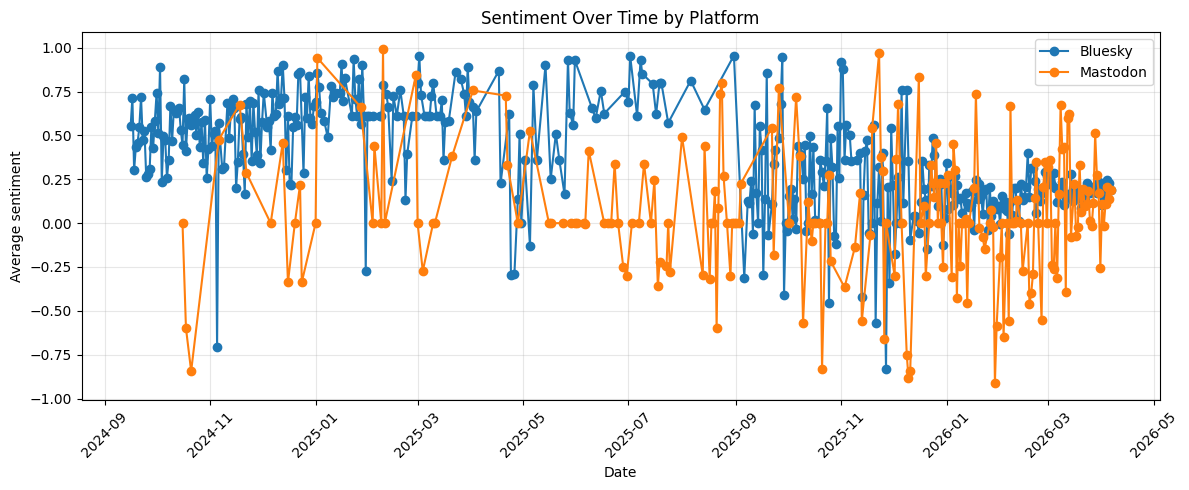

In [58]:
# Combine all text from both platforms
all_texts = []
if all_bluesky_posts:
    df_bsky = pd.DataFrame(all_bluesky_posts)
    df_bsky['platform'] = 'Bluesky'
    all_texts.append(df_bsky)
if all_mastodon_toots:
    df_mast = pd.DataFrame(all_mastodon_toots)
    df_mast['platform'] = 'Mastodon'
    all_texts.append(df_mast)

if all_texts:
    combined_df = pd.concat(all_texts, ignore_index=True)
    
    # Sentiment analysis
    analyzer = SentimentIntensityAnalyzer()
    combined_df['sentiment'] = combined_df['text'].fillna('').apply(lambda x: analyzer.polarity_scores(x)['compound'])
    
    # Wordcloud
    all_words = " ".join(combined_df['text'].fillna(''))
    stopwords = ['the', 'and', 'to', 'of', 'a', 'in', 'for', 'on', 'with', 'is', 'that', 'it', 'this', 'are', 'as', 'at', 'be', 'by', 'from', 'has', 'have', 'was', 'were', 'you', 'your', 'game', 'games', 'like', 'just', 'can', 'will', 'not', 'but', 'so', 'if', 'then', 'all', 'no', 'one', 'two', 'three', 'get', 'got', 'go', 'play', 'playing', 'played', 'amp', 'gt', 'lt']
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords, max_words=100).generate(all_words)
    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most frequent words in Bluesky & Mastodon posts')
    plt.show()
    
    # Topic modeling
    vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english', max_features=1000)
    dtm = vectorizer.fit_transform(combined_df['text'].fillna('').tolist())
    lda = LatentDirichletAllocation(n_components=5, random_state=42)
    lda.fit(dtm)
    feature_names = vectorizer.get_feature_names_out()
    print("\nTopic Modeling Results (LDA):")
    for topic_idx, topic in enumerate(lda.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-10:]]
        print(f"Topic {topic_idx+1}: {', '.join(top_words)}")
    
    # Sentiment distribution by platform
    print("\nAverage sentiment by platform:")
    print(combined_df.groupby('platform')['sentiment'].mean())
    
    # Sentiment over time – FIXED: use format='ISO8601' or errors='coerce'
    if 'created_at' in combined_df.columns:
        # Try to parse ISO8601 strings
        combined_df['date'] = pd.to_datetime(combined_df['created_at'], format='ISO8601', errors='coerce')
        # Drop rows with invalid dates
        combined_df = combined_df.dropna(subset=['date'])
        if not combined_df.empty:
            daily_sentiment = combined_df.groupby([combined_df['date'].dt.date, 'platform'])['sentiment'].mean().reset_index()
            plt.figure(figsize=(12,5))
            for platform in daily_sentiment['platform'].unique():
                sub = daily_sentiment[daily_sentiment['platform'] == platform]
                plt.plot(sub['date'], sub['sentiment'], marker='o', label=platform)
            plt.xlabel('Date')
            plt.ylabel('Average sentiment')
            plt.title('Sentiment Over Time by Platform')
            plt.legend()
            plt.xticks(rotation=45)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("No valid dates for sentiment time series.")
else:
    print("No text data for supplementary analysis.")

In [59]:
# ============================================================================
# Cell 6: Export Final Results for Report (including Reddit)
# ============================================================================
def save_network_metrics(G, platform_name):
    if G.number_of_nodes() == 0:
        return
    metrics = []
    pagerank = nx.pagerank(G)
    for node in G.nodes():
        metrics.append({
            'user': node,
            'in_degree': G.in_degree(node),
            'out_degree': G.out_degree(node),
            'pagerank': pagerank.get(node, 0)
        })
    df = pd.DataFrame(metrics).sort_values('pagerank', ascending=False)
    df.to_csv(f"{config.OUTPUT_DIR}/{platform_name}_influencers.csv", index=False)
    print(f"Saved {platform_name} influencer metrics to CSV.")

# Save Bluesky (if exists)
if 'combined_bluesky' in locals() and combined_bluesky.number_of_nodes() > 0:
    save_network_metrics(combined_bluesky, "Bluesky")
else:
    print("Bluesky network not available.")

# Save Mastodon (if exists)
if 'combined_mastodon' in locals() and combined_mastodon.number_of_nodes() > 0:
    save_network_metrics(combined_mastodon, "Mastodon")
else:
    print("Mastodon network not available.")

# Save Reddit (if exists)
if 'combined_reddit' in locals() and combined_reddit.number_of_nodes() > 0:
    save_network_metrics(combined_reddit, "Reddit")
else:
    print("Reddit network not available.")

print("\nAll descriptive analyses complete. Results saved in 'data/' folder.")

Saved Bluesky influencer metrics to CSV.
Saved Mastodon influencer metrics to CSV.
Saved Reddit influencer metrics to CSV.

All descriptive analyses complete. Results saved in 'data/' folder.
